In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scienceplots
import seaborn as sns

from nanonets import Simulation
from nanonets.utils import load_simulation_results

plt.style.use(["science","bright","grid"])

# PARAMETERS
M_VALS  = [1,2,4,8,16,32,64,128,256,512,1024,2048,4096,8192,16384]
L       = [9]
R_VALS  = [100,1600]
N_NETS  = 32
PATH    = "/mnt/c/Users/jonas/Desktop/phd/data/1_funding_period/iv_curves/stats_eq_jumps_res_disorder/"

# INPUT VOLTAGES
V_INPUT_MAX = 0.2
N_INPUTS    = 5
V_INPUT     = np.round(np.linspace(0.03, V_INPUT_MAX, N_INPUTS),4)

In [16]:
df = pd.DataFrame()
for R in R_VALS:
    for i in range(N_NETS):
        for M in M_VALS:
            try:
                df_tmp      = pd.read_csv(f"{PATH}Nx=9_Ny=9_Ne=8_{M}_{R}_{i}.csv")
                df_tmp['R'] = R
                df_tmp['i'] = i
                df          = pd.concat([df,df_tmp],ignore_index=True)
            except:
                pass

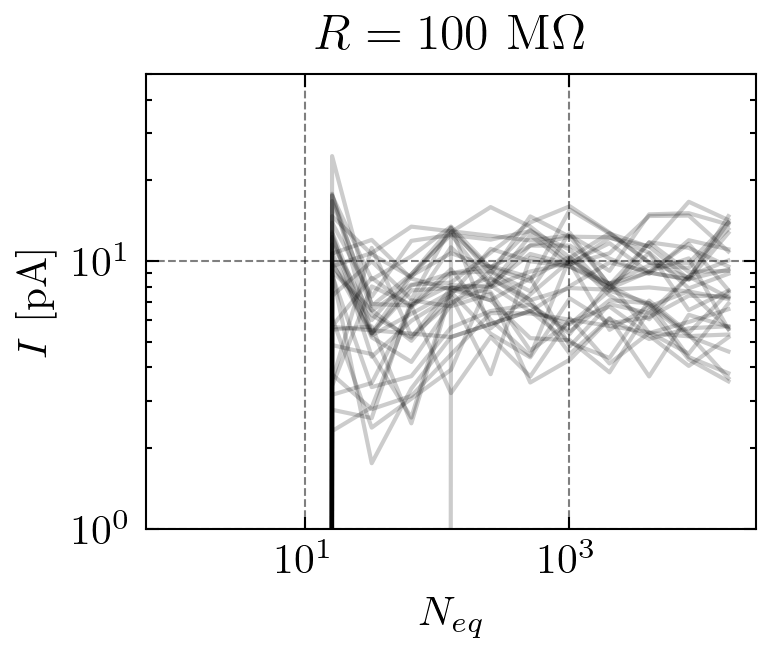

In [27]:
R       = 100
j       = 0
df_tmp  = df.copy()
df_tmp  = df_tmp[df_tmp['E0']==V_INPUT[j]]
df_tmp  = df_tmp[df_tmp['R']==R]

fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)

for i in range(N_NETS):
    val = df_tmp[df_tmp['i']==i]
    _   = ax.plot(val['Eq_Jumps'], val['Observable']*1e-6, color='black', alpha=0.2)
    # _   = ax.errorbar(val['Eq_Jumps'], val['Observable']*1e-6, val['Error']*1e-6)

_   = ax.set_xscale('log')
_   = ax.set_yscale('log')
_   = ax.set_xlabel("$N_{eq}$")
_   = ax.set_ylabel("$I~[\mathrm{pA}]$")
_   = ax.set_ylim(1,50)
_   = ax.set_title(f"$R = {R}~\mathrm{{M\Omega}}$")

# fig.savefig(f"plots/svg/current_vs_eq_jumps_low_T.svg", transparent=True)
# fig.savefig(f"plots/pdf/current_vs_eq_jumps_low_T.pdf", transparent=False)
# fig.savefig(f"plots/png/current_vs_eq_jumps_low_T.png", transparent=False)

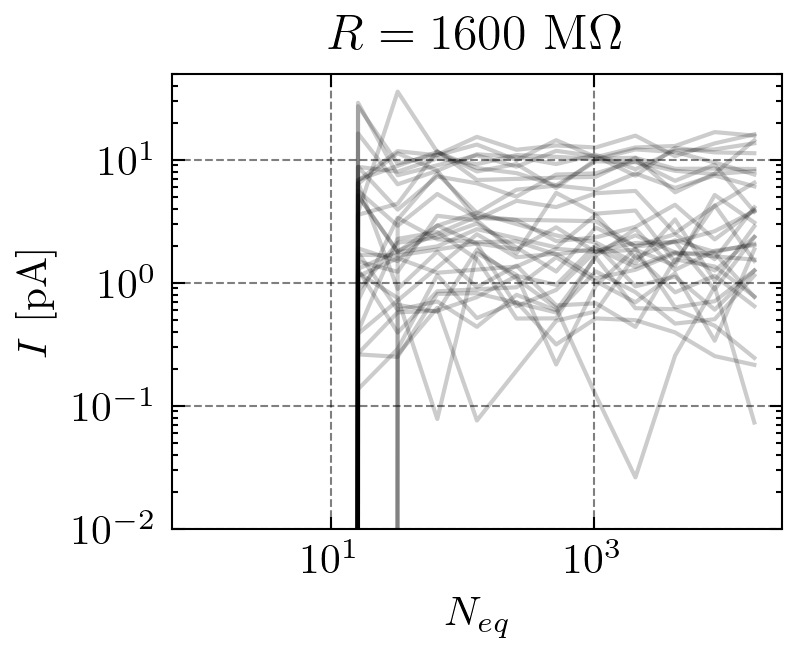

In [26]:
R       = 1600
j       = 0
df_tmp  = df.copy()
df_tmp  = df_tmp[df_tmp['E0']==V_INPUT[j]]
df_tmp  = df_tmp[df_tmp['R']==R]

fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)

for i in range(N_NETS):
    val = df_tmp[df_tmp['i']==i]
    _   = ax.plot(val['Eq_Jumps'], val['Observable']*1e-6, color='black', alpha=0.2)
    # _   = ax.errorbar(val['Eq_Jumps'], val['Observable']*1e-6, val['Error']*1e-6)

_   = ax.set_xscale('log')
_   = ax.set_yscale('log')
_   = ax.set_xlabel("$N_{eq}$")
_   = ax.set_ylabel("$I~[\mathrm{pA}]$")
_   = ax.set_ylim(0.01,50)
_   = ax.set_title(f"$R = {R}~\mathrm{{M\Omega}}$")

# fig.savefig(f"plots/svg/current_vs_eq_jumps_low_T.svg", transparent=True)
# fig.savefig(f"plots/pdf/current_vs_eq_jumps_low_T.pdf", transparent=False)
# fig.savefig(f"plots/png/current_vs_eq_jumps_low_T.png", transparent=False)